In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ast

matrix = pd.read_csv("prs_adjauc_matrix_binary_extend.csv")
matrix.columns = matrix.columns.str.replace("_hmPOS_GRCh38", "", regex=False)
pgs_map = pd.read_csv("../../measurement_preprocess/pgs_id_list_260225.csv") 
icd_pgs_map = pd.read_csv("../../disease_preprocess/pgs_id_list_binary_combined.csv") 

### QC

In [3]:
# generate a mapping between pgs id and icd id, change colname, set trait information as index
from collections import defaultdict
print("Before filter:", matrix.shape)

# get mapping between PGS id and icd code
pgs2icds = defaultdict(set)
for idx, row in pgs_map.iterrows():
    pgs_ids = ast.literal_eval(row['pgs_ids'])
    icd_code = row['loinc']

    for pgs in pgs_ids:
        pgs2icds[pgs].add(icd_code)

for idx, row in icd_pgs_map.iterrows():
    pgs_ids = ast.literal_eval(row['pgs_ids'])
    icd_code = row['icd']

    for pgs in pgs_ids:
        pgs2icds[pgs].add(icd_code)

# rename each col
matrix = matrix.set_index("trait")
new_columns = []
for col in matrix.columns:
    if col in pgs2icds:
        icd_list = "+".join(pgs2icds[col])
        new_columns.append(f"{icd_list}__{col}")
    else:
        new_columns.append(f"NA__{col}")

matrix.columns = new_columns
print("After filter:", matrix.shape)

Before filter: (348, 3197)
After filter: (348, 3196)


In [4]:
# check how many pgs for each trait is calculated
matrix_df = matrix.copy()
prs_count = {}

for trait in matrix_df.index:
    count = 0
    
    for col in matrix_df.columns:
        if "__" not in col:
            continue
        
        icd_part = col.split("__")[0]      # C44+C43
        icd_list = icd_part.split("+")     # ["C44","C43"]

        if trait in icd_list:
            count += 1

    prs_count[trait] = count

prs_count_df = pd.DataFrame.from_dict(
    prs_count,
    orient="index",
    columns=["calc_prs_count"]
)

prs_count_df = prs_count_df.reset_index()
prs_count_df = prs_count_df.rename(columns={"index": "loinc"})

In [5]:
# save data after QC
matrix.to_csv("prs_adjauc_matrix_binary_extend_qc.csv", index=True)
print("Data shape after QC:", matrix.shape)

Data shape after QC: (348, 3196)


### Save Rank Matrix

In [6]:
import numpy as np
matrix = pd.read_csv("prs_adjauc_matrix_binary_extend_qc.csv")
matrix = matrix.set_index("trait")
matrix = matrix.apply(pd.to_numeric, errors='coerce') 

# check how many pgs for each trait is calculated
matrix_df = matrix.copy()
prs_count = {}

for trait in matrix_df.index:
    count = 0
    
    for col in matrix_df.columns:
        if "__" not in col:
            continue
        
        icd_part = col.split("__")[0]      # C44+C43
        icd_list = icd_part.split("+")     # ["C44","C43"]

        if trait in icd_list:
            count += 1

    prs_count[trait] = count

prs_count_df = pd.DataFrame.from_dict(
    prs_count,
    orient="index",
    columns=["calc_prs_count"]
)

prs_count_df = prs_count_df.reset_index()
prs_count_df = prs_count_df.rename(columns={"index": "loinc"})

# save ranking matrix 
rank_rows = []
for trait in matrix_df.index: 
    row = matrix_df.loc[trait].sort_values(ascending=False) 
    rank_rows.append(row.index.tolist())
rank_df = pd.DataFrame(
    rank_rows,
    index=matrix_df.index,
    columns=[f"rank_{i+1}" for i in range(matrix_df.shape[1])]
)
rank_df.to_csv("prs_adjauc_matrix_binary_extend_rankmatrix.csv", index=True)

In [7]:
# save rank matrix: each row only ranks its own PGS (self-PGS only)
self_rank_rows = []
self_rank_counts = []

for trait in matrix_df.index:
    # filter to columns whose ICD part contains this trait
    self_cols = [
        col for col in matrix_df.columns
        if "__" in col and trait in col.split("__")[0].split("+")
    ]
    if self_cols:
        row = matrix_df.loc[trait, self_cols].sort_values(ascending=False)
        self_rank_rows.append(row.index.tolist())
        self_rank_counts.append(len(self_cols))
    else:
        self_rank_rows.append([])
        self_rank_counts.append(0)

max_self_pgs = max(self_rank_counts)
padded = [r + [None] * (max_self_pgs - len(r)) for r in self_rank_rows]

self_rank_df = pd.DataFrame(
    padded,
    index=matrix_df.index,
    columns=[f"rank_{i+1}" for i in range(max_self_pgs)]
)
self_rank_df.to_csv("prs_adjauc_matrix_binary_extend_selfrankmatrix.csv", index=True)
print("Self-PGS rank matrix shape:", self_rank_df.shape)
print(self_rank_df.head())

Self-PGS rank matrix shape: (348, 0)
Empty DataFrame
Columns: []
Index: [A04, A08, A41, A49, A60]


### Overall Performance

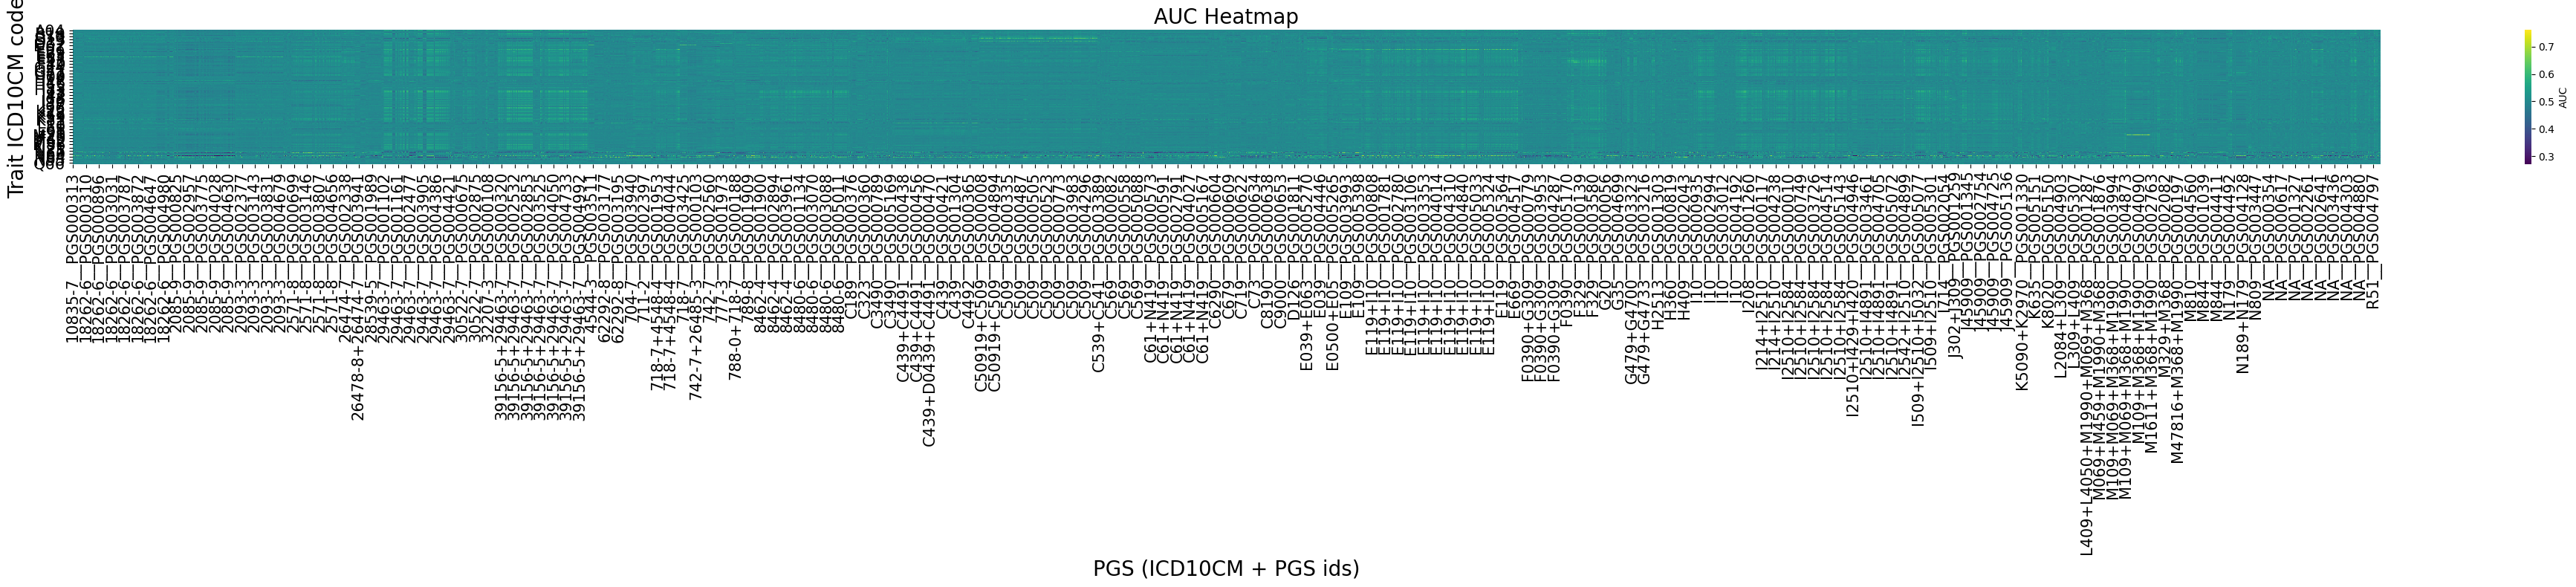

In [8]:
matrix_df = matrix.copy()
matrix_df = matrix_df.sort_index(axis=0)  # 按 trait 排序
matrix_df = matrix_df.sort_index(axis=1)  # 按 ICD / PGS 排序

plt.figure(figsize=(40, 8))
sns.heatmap(matrix_df, cmap="viridis", cbar_kws={'label': 'AUC'})
plt.xlabel("PGS (ICD10CM + PGS ids)", fontsize=20)
plt.ylabel("Trait ICD10CM code", fontsize=20)
plt.title("AUC Heatmap", fontsize=20)
plt.xticks(rotation=90, fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

In [9]:
top_n = 5
top_n_prs_df = {}

for trait in matrix_df.index:
    top_prs = matrix_df.loc[trait].sort_values(ascending=False).head(top_n)
    top_n_prs_df[trait] = top_prs

best_prs = matrix_df.idxmax(axis=1)
best_auc = matrix_df.max(axis=1)

top_prs_df = pd.DataFrame({
    "trait": matrix_df.index,
    "best_prs": best_prs.values,
    "best_auc": best_auc.values
})

print(top_prs_df)

    trait                         best_prs  best_auc
0     A04                  F329__PGS004760  0.550887
1     A08                  F329__PGS004760  0.548557
2     A41       39156-5+29463-7__PGS005203  0.586513
3     A49  M109+M069+M368+M1990__PGS004819  0.557953
4     A60                  F329__PGS003333  0.539771
..    ...                              ...       ...
343   Q61       I219+I214+I2510__PGS004458  0.543216
344   Q66               29463-7__PGS005234  0.532309
345   Q76                    NA__PGS000781  0.537761
346   Q79                   R51__PGS004800  0.552321
347   Q82               29463-7__PGS001160  0.529216

[348 rows x 3 columns]
